In [2]:
pip install mne numpy matplotlib

In [12]:
import mne

# Load raw FIF file
raw = mne.io.read_raw_fif("Dataset\subject1.raw.fif", preload=True)

Opening raw data file Dataset\subject1.raw.fif...


<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\soham\AppData\Local\Temp\ipykernel_11072\753594461.py:4: SyntaxWarning: invalid escape sequence '\s'
  raw = mne.io.read_raw_fif("Dataset\subject1.raw.fif", preload=True)


Isotrak not found
    Range : 0 ... 254784 =      0.000 ...   497.625 secs
Ready.
Reading 0 ... 254784  =      0.000 ...   497.625 secs...


In [13]:
print(raw.info)

<Info | 9 non-empty values
 bads: []
 ch_names: Fpz, F7, F3, Fz, F4, F8, T7, C3, Cz, C4, T8, P7, P3, Pz, P4, P8, ...
 chs: 16 EEG, 1 Stimulus
 custom_ref_applied: False
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 1970-01-01 00:00:00 UTC
 meas_id: 4 items (dict)
 nchan: 17
 projs: []
 sfreq: 512.0 Hz
>


<IPython.core.display.Javascript object>

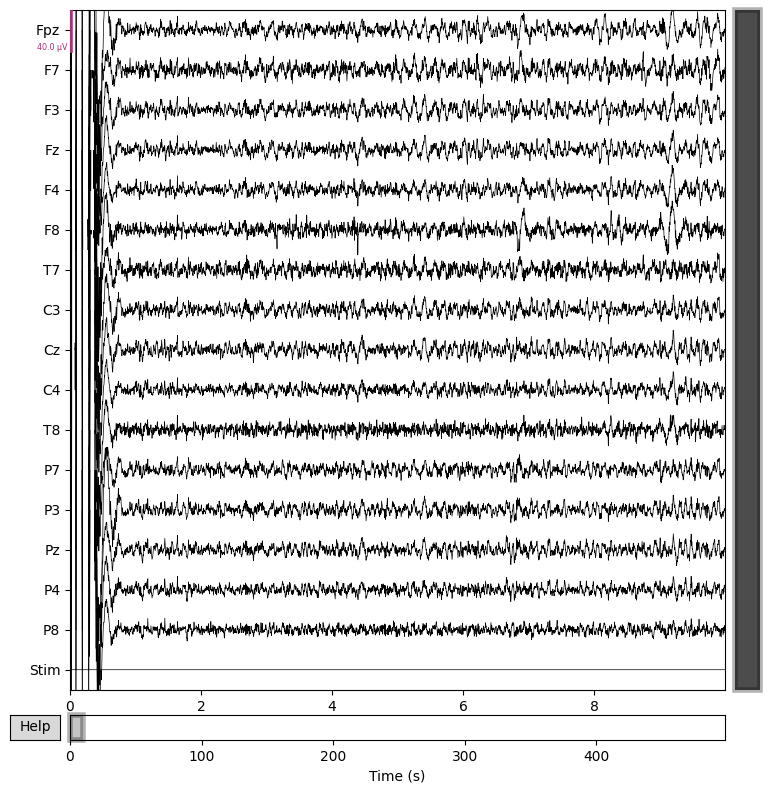

In [14]:
raw.plot()

In [15]:
print(raw.info)

<Info | 9 non-empty values
 bads: []
 ch_names: Fpz, F7, F3, Fz, F4, F8, T7, C3, Cz, C4, T8, P7, P3, Pz, P4, P8, ...
 chs: 16 EEG, 1 Stimulus
 custom_ref_applied: False
 file_id: 4 items (dict)
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 1970-01-01 00:00:00 UTC
 meas_id: 4 items (dict)
 nchan: 17
 projs: []
 sfreq: 512.0 Hz
>


In [18]:
raw.pick_channels(['C3','C4','Cz','T7','T8','F3','F4','P3','P4'])

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


<Raw | subject1.raw.fif, 9 x 254785 (497.6 s), ~17.5 MiB, data loaded>

In [19]:
raw_mu = raw.copy().filter(8, 12)    # mu band
raw_beta = raw.copy().filter(13, 30) # beta band

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 845 samples (1.650 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge:

In [20]:
raw.notch_filter(50)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3381 samples (6.604 s)



<Raw | subject1.raw.fif, 9 x 254785 (497.6 s), ~17.5 MiB, data loaded>

In [22]:
from mne.preprocessing import ICA

num_components = 9 
ica = ICA(n_components=num_components, method='fastica')
ica.fit(raw)

Fitting ICA to data using 9 channels (please be patient, this may take a while)


C:\Users\soham\AppData\Local\Temp\ipykernel_11072\939575738.py:5: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Selecting by number: 9 components
Fitting ICA took 8.2s.


Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,49 iterations on raw data (254785 samples)
ICA components,9
Available PCA components,9
Channel types,eeg
ICA components marked for exclusion,—


<IPython.core.display.Javascript object>

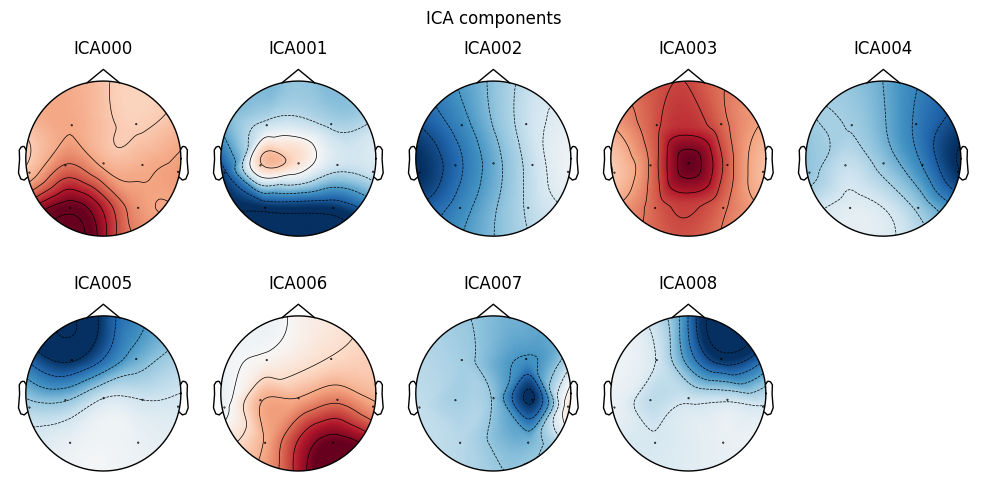

In [23]:
ica.plot_components()

In [25]:
raw.plot(n_channels=9, scalings=dict(eeg=100e-6));

<IPython.core.display.Javascript object>

In [26]:
ica.plot_properties(raw, picks=0)

<IPython.core.display.Javascript object>

    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
248 matching events found
No baseline correction applied
0 projection items activated


[<Figure size 700x600 with 6 Axes>]

Applying ICA to Raw instance
    Transforming to ICA space (9 components)
    Zeroing out 1 ICA component
    Projecting back using 9 PCA components


<IPython.core.display.Javascript object>

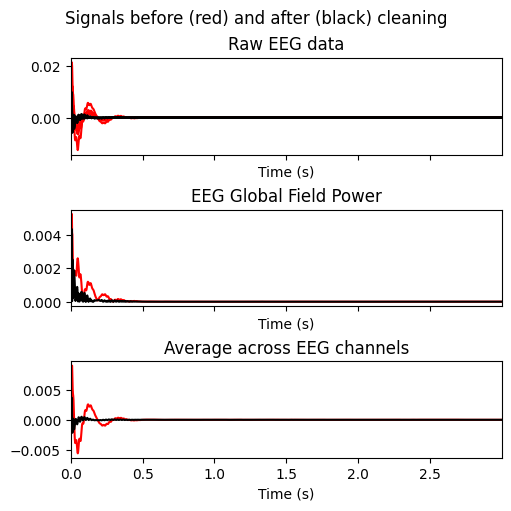

In [27]:
ica.plot_overlay(raw, exclude=[0])

In [28]:
ica.exclude = [0]
ica.apply(raw)

Applying ICA to Raw instance
    Transforming to ICA space (9 components)
    Zeroing out 1 ICA component
    Projecting back using 9 PCA components


<Raw | subject1.raw.fif, 9 x 254785 (497.6 s), ~17.5 MiB, data loaded>

<IPython.core.display.Javascript object>

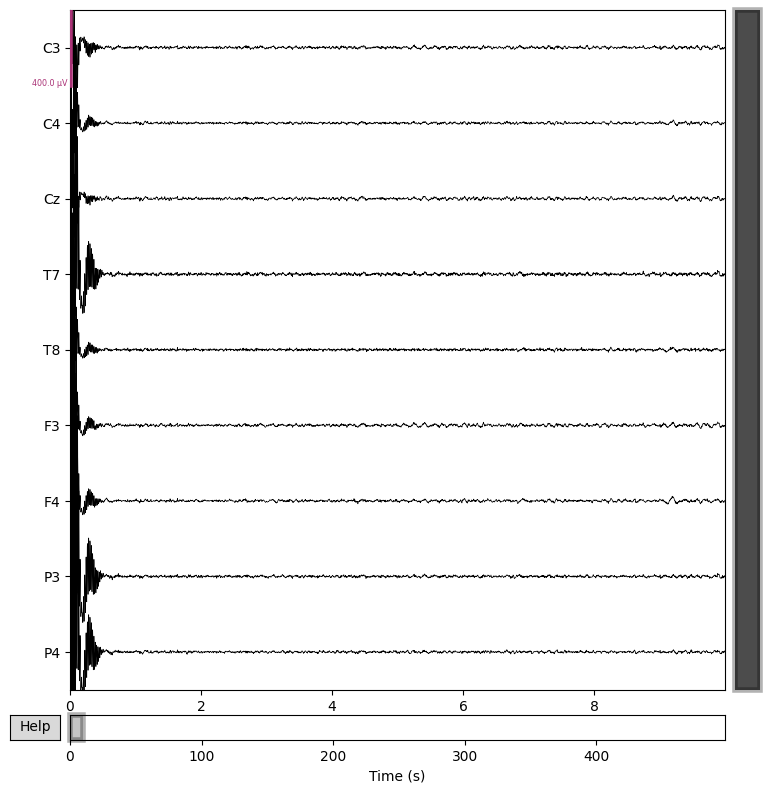

In [30]:
raw.plot(scalings=dict(eeg=200e-6))